In [384]:
###=========================

# Author: Ruhan Gandhi 
# Purpose: Machine learning exploratory analysis for brain age prediction 


# import relevant packcages 

import pandas as pd
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline 
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Load your dataset

import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('training_validation.csv')



# Define features and target variable
X = df.drop(['Age', 'ID', 'Diagnosis', 'FieldStrength'], axis=1)
y = df['Age']

X

,3rdVentricle,4thVentricle,RightAccumbensArea,LeftAccumbensArea,RightAmygdala,LeftAmygdala,BrainStem,RightCaudate,LeftCaudate,RightCerebellumExterior,...,AsymmetrySTG,AsymmetryTMP,AsymmetryTrIFG,AsymmetryTTG,AsymmetryBrain,AsymmetryBrainTissue,AsymmetryVentricles,AsymmetryCGM,AsymmetryDGM,AsymmetryWM
0,4359.5,4984.4,431.1,400.9,1460.7,1524.7,21409.5,4190.0,3589.6,52396.2,...,14.035219,2.037072,11.800233,5.386740,1.336421,0.987901,4.758436,0.187927,0.622519,2.387750
1,3321.0,3475.2,502.1,430.6,818.0,882.0,22208.9,7238.1,9047.2,49444.3,...,14.500217,4.825227,4.203818,1.129944,0.160045,2.209861,30.842461,1.934403,0.002198,3.148946
2,1525.2,1862.7,397.8,378.9,1293.3,1248.1,20148.1,3595.2,3602.8,54652.6,...,5.404970,2.421890,8.600695,4.985006,1.005277,1.240222,4.708337,0.019371,2.790771,2.073514
3,1835.8,1965.5,400.6,334.8,1115.4,927.3,19740.1,2966.2,2766.8,55165.2,...,4.477032,0.850257,22.336532,3.993044,1.788597,1.842156,0.485035,2.397467,2.696684,0.930847
4,2946.5,1628.9,188.7,233.5,745.2,958.4,18544.8,2262.1,2406.0,46316.2,...,5.854615,22.622367,12.123449,8.998875,1.679182,1.359046,8.623602,3.248992,2.827620,1.251867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1334,2359.2,2497.2,356.4,380.4,1076.4,1114.8,21410.4,3514.8,3108.0,56142.0,...,9.731632,7.123835,20.415670,7.939509,2.587910,2.725055,0.881533,2.487841,0.952211,3.799815
1335,1386.0,2577.6,370.8,354.0,990.0,1168.8,20271.6,3691.2,3420.0,55471.2,...,10.347752,18.426815,12.998233,37.403651,0.633922,0.743272,3.520594,0.513888,0.958117,1.991476
1336,1590.0,1754.4,368.4,457.2,1341.6,1302.0,20006.4,3534.0,3716.4,55986.0,...,5.880813,14.499139,27.945593,17.249877,0.432528,0.259851,19.826793,0.325164,0.186906,1.165280
1337,1340.4,1758.0,242.4,288.0,1171.2,1262.4,16170.0,2677.2,2396.4,42028.8,...,3.424378,5.136594,23.001168,23.056703,0.570490,1.114353,9.956462,0.900259,0.724246,1.547588


Percentage of missing values in each column of X:
3rdVentricle            0.0
4thVentricle            0.0
RightAccumbensArea      0.0
LeftAccumbensArea       0.0
RightAmygdala           0.0
                       ... 
AsymmetryBrainTissue    0.0
AsymmetryVentricles     0.0
AsymmetryCGM            0.0
AsymmetryDGM            0.0
AsymmetryWM             0.0
Length: 292, dtype: float64


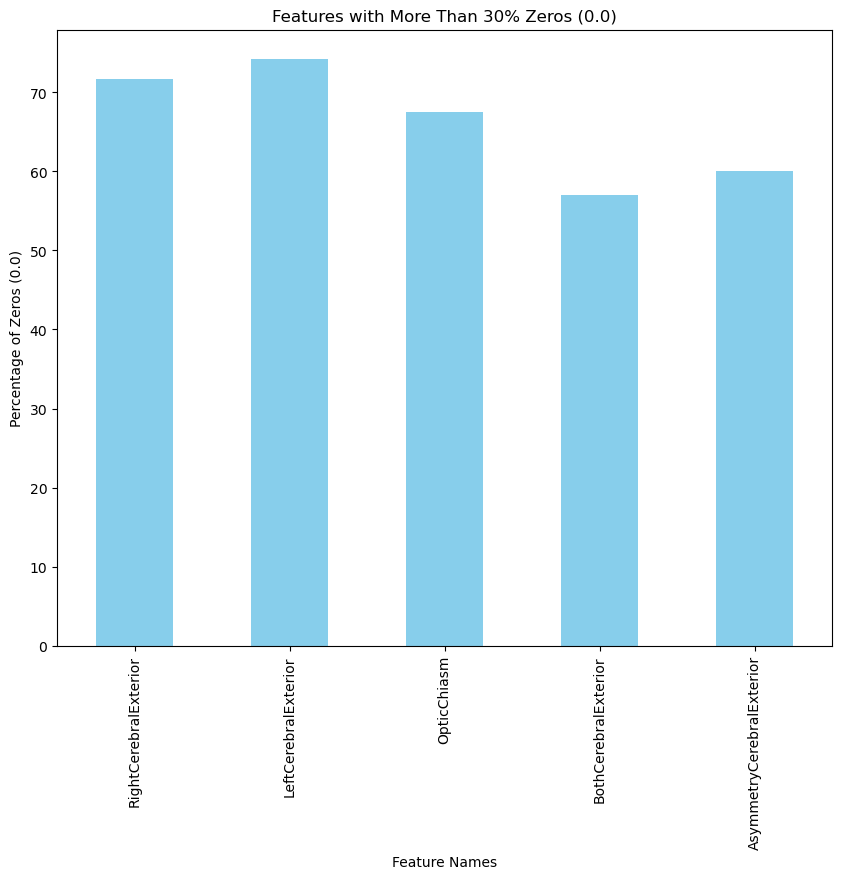

Features with more than 30% zeros (0.0): ['RightCerebralExterior', 'LeftCerebralExterior', 'OpticChiasm', 'BothCerebralExterior', 'AsymmetryCerebralExterior']


(1339, 287)

In [385]:
#========================

# Step 1: pre-processing 

# we will be checking for outliers, missing values and ivestigating any linear relationships present in the dataset 


#===========================


# Outliers in dataset: 
# checking age distrubution 


import seaborn as sns



# from the age distribution, seems to be a few people aged lower than 5, but the most common range is between 60-85 
# thus remove these outliers in original code above 


####

# investigating missing values: 

missing_percentage = (X.isnull().sum() / len(X)) * 100
print("Percentage of missing values in each column of X:")
print(missing_percentage)

# there are no missing values, however, some brain regions have columns with brain regions = 0??? how can brain regions = 0 



percentage_zeros = (X == 0.0).mean() * 100
columns_with_zeros = percentage_zeros[percentage_zeros > 30]


plt.figure(figsize=(10, 8))
columns_with_zeros.plot(kind='bar', color='skyblue')
plt.title('Features with More Than 30% Zeros (0.0)')
plt.xlabel('Feature Names')
plt.ylabel('Percentage of Zeros (0.0)')
plt.show()

# there are 5 feaures where the value is 0, which is not good 
# hence we will remove those 5 features 


columns_with_zeros_list = columns_with_zeros.index.tolist()
print("Features with more than 30% zeros (0.0):", columns_with_zeros_list)



X = X.drop(['RightCerebralExterior', 'LeftCerebralExterior', 'OpticChiasm', 'BothCerebralExterior', 'AsymmetryCerebralExterior'], axis = 1 )
X.shape 


# run the top section of code before running this again 

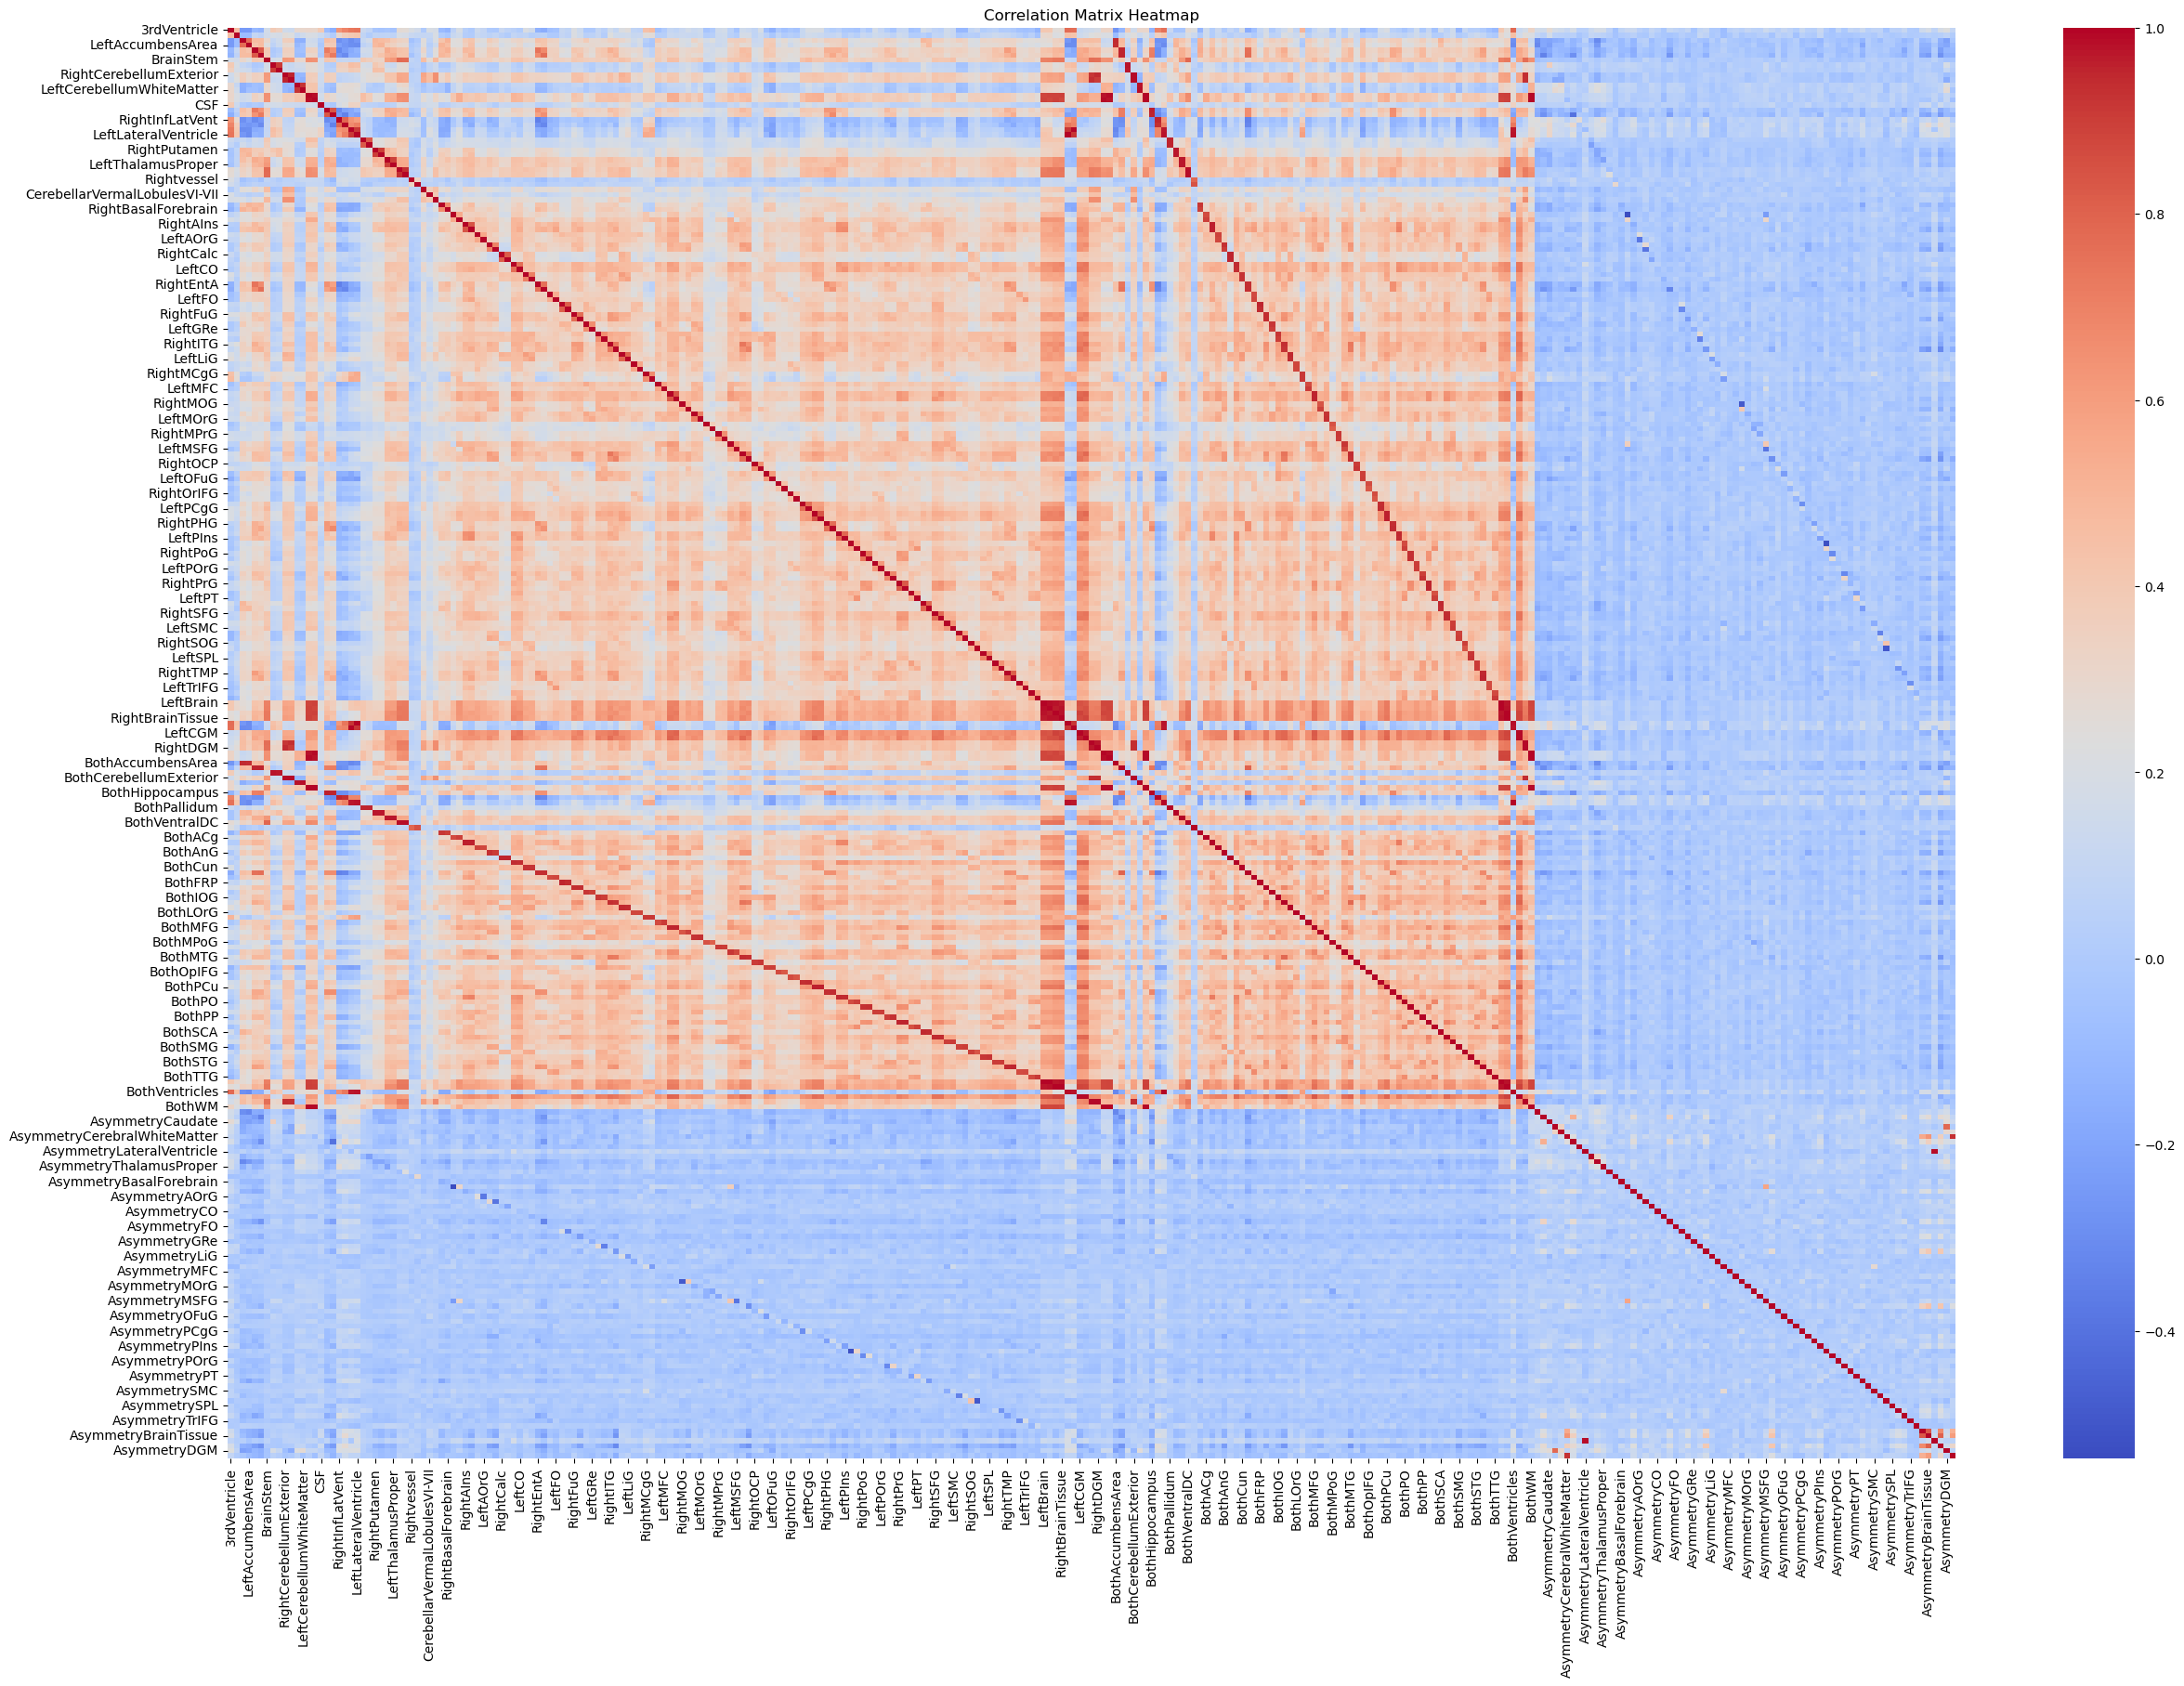

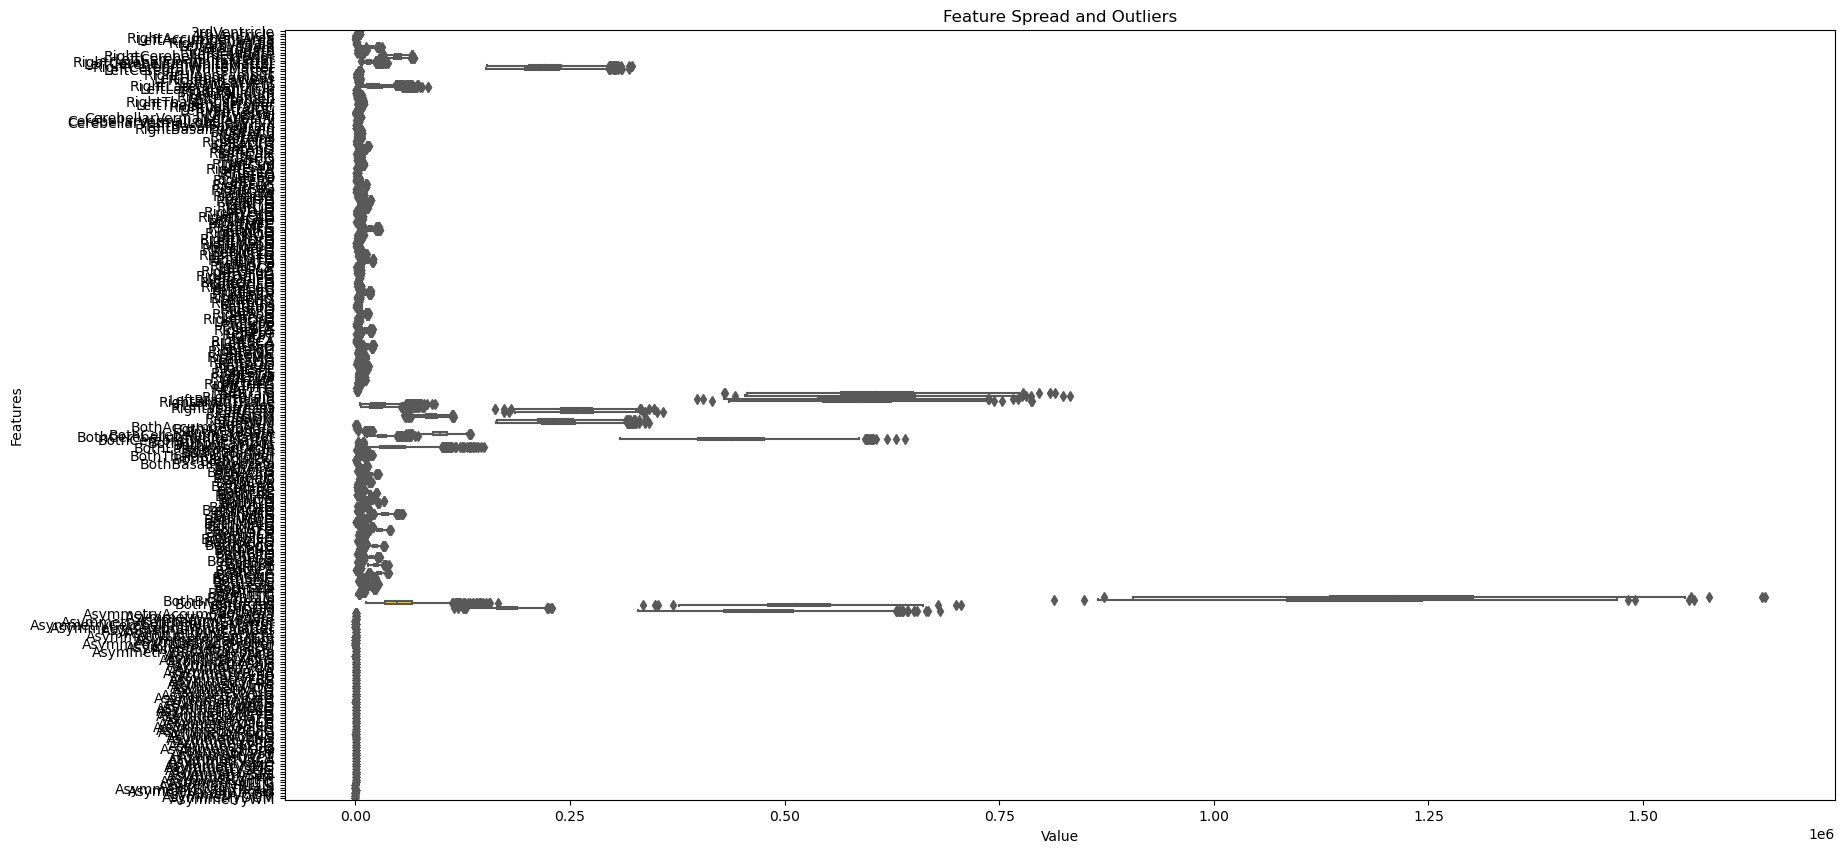

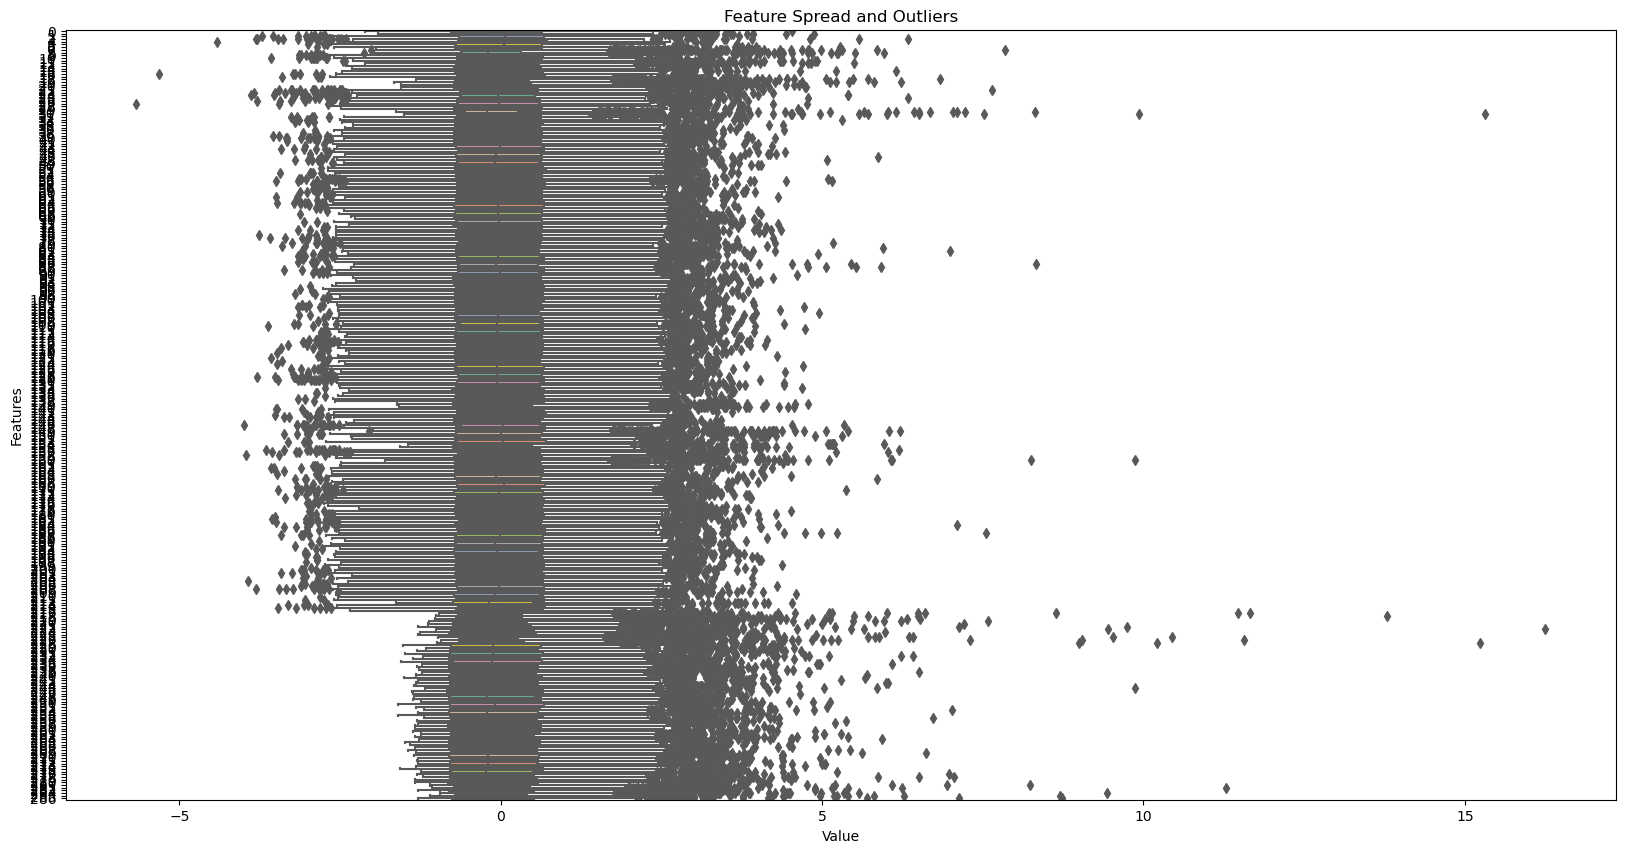

In [365]:
# still pre-processing/ part 2 : 
# use correlation matrix to make sure that there may be cases of multi-colinearitty
# overall it seems ok


corr_matrix = X.corr()

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(30, 20))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()
 
    
# effects of scaling the data
# here we used  standard scaler,to inspect what teh standardized data looks like
# standard scaler will be implemented within the analysis pipelines and final Pipeline 


plt.figure(figsize=(20,10))
sns.boxplot(data=X, orient="h", palette="Set2")
plt.title('Feature Spread and Outliers')
plt.xlabel('Value')
plt.ylabel('Features')
plt.show()





from sklearn.preprocessing import StandardScaler
normalizer = StandardScaler()
X_normalized = normalizer.fit_transform(X)

plt.figure(figsize=(20,10))
sns.boxplot(data=X_normalized, orient="h", palette="Set2")
plt.title('Feature Spread and Outliers')
plt.xlabel('Value')
plt.ylabel('Features')
plt.show()





In [119]:
# Pre-processing part 3:

# grid searching for the best hyperaramters for each model
# my plan is to use 2 linear regression models, 1 non-linear regression models and 2 decision tree based models 
# do not run the grid search here, do each one in another section, this is just for compling in one place 
# below this section, there will be a list of the models with their optimized hyper-paramters from the grid search 


from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.svm import SVR


#=================================================================


# XGB and random forrest grid search: 



param_grid = {
    'max_depth': [3, 4, 5, 6],  # Example depths, adjust based on your dataset
    'alpha': [0, 0.5, 1, 1.5],  # L1 regularization terms
    'learning_rate': [0.01, 0.1, 0.2, 0.3]  # Learning rate values
}

xgb_model = xgb.XGBRegressor()
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X, y)

#best_params = grid_search.best_params_
#print("Best parameters:", best_params)




# Random forrest 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
random_forest = RandomForestRegressor(random_state=42)


param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
      
}


grid_search = GridSearchCV(estimator=random_forest, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)


print("Best parameters:", grid_search.best_params_)
print("Best score (neg_mean_squared_error):", grid_search.best_score_)










#===============================================================



#Linear regression grid searches (for lasso and ridge, interchangabel): 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lasso = Lasso()
param_grid = {
    'alpha': [0.1, 1, 10, 100, 1000]
}

grid_search = GridSearchCV(estimator=lasso, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)
grid_search.fit(X_train, y_train)


print("Best parameters:", grid_search.best_params_)
print("Best score (neg_mean_squared_error):", grid_search.best_score_)


#========================================================================



#non_linear: 


pipeline = Pipeline([
    ('scaler', StandardScaler()),  =
    ('svr', SVR())
])


param_grid = {
    'svr__C': [0.1, 1, 10],  # Regularization parameter
    'svr__epsilon': [0.01, 0.1, 0.5],  # Epsilon in the epsilon-SVR model
}  


grid_search = GridSearchCV(estimator=svr_pipeline, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)
grid_search.fit(X_train, y_train)


print("Best parameters:", grid_search.best_params_)
print("Best score (neg_mean_squared_error):", grid_search.best_score_)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


/Users/ruhangandhi/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/ruhangandhi/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/ruhangandhi/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/ruhangandhi/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/ruhangandhi/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:6

Best parameters: {'alpha': 1.5, 'learning_rate': 0.1, 'max_depth': 4}
[CV] END ...........alpha=0, learning_rate=0.01, max_depth=3; total time=   1.2s
[CV] END ...........alpha=0, learning_rate=0.01, max_depth=5; total time=   4.2s
[CV] END ............alpha=0, learning_rate=0.1, max_depth=3; total time=   1.2s
[CV] END ............alpha=0, learning_rate=0.1, max_depth=3; total time=   1.0s
[CV] END ............alpha=0, learning_rate=0.1, max_depth=4; total time=   2.1s
[CV] END ............alpha=0, learning_rate=0.1, max_depth=5; total time=   3.6s
[CV] END ............alpha=0, learning_rate=0.1, max_depth=6; total time=   6.1s
[CV] END ............alpha=0, learning_rate=0.2, max_depth=5; total time=   3.5s
[CV] END ............alpha=0, learning_rate=0.3, max_depth=3; total time=   1.0s
[CV] END ............alpha=0, learning_rate=0.3, max_depth=4; total time=   1.9s
[CV] END ............alpha=0, learning_rate=0.3, max_depth=5; total time=   4.0s
[CV] END ............alpha=0, learning_

[CV] END ...........alpha=0, learning_rate=0.01, max_depth=3; total time=   1.1s
[CV] END ...........alpha=0, learning_rate=0.01, max_depth=4; total time=   2.2s
[CV] END ...........alpha=0, learning_rate=0.01, max_depth=6; total time=   7.3s
[CV] END ............alpha=0, learning_rate=0.1, max_depth=5; total time=   3.6s
[CV] END ............alpha=0, learning_rate=0.1, max_depth=6; total time=   5.8s
[CV] END ............alpha=0, learning_rate=0.2, max_depth=6; total time=   5.5s
[CV] END ............alpha=0, learning_rate=0.3, max_depth=4; total time=   2.1s
[CV] END ............alpha=0, learning_rate=0.3, max_depth=6; total time=   6.3s
[CV] END .........alpha=0.5, learning_rate=0.01, max_depth=5; total time=   4.0s
[CV] END .........alpha=0.5, learning_rate=0.01, max_depth=6; total time=   7.7s
[CV] END ..........alpha=0.5, learning_rate=0.1, max_depth=6; total time=   6.8s
[CV] END ..........alpha=0.5, learning_rate=0.2, max_depth=5; total time=   3.9s
[CV] END ..........alpha=0.5

[CV] END ...........alpha=0, learning_rate=0.01, max_depth=3; total time=   1.1s
[CV] END ...........alpha=0, learning_rate=0.01, max_depth=5; total time=   4.0s
[CV] END ...........alpha=0, learning_rate=0.01, max_depth=6; total time=   7.7s
[CV] END ............alpha=0, learning_rate=0.1, max_depth=6; total time=   5.9s
[CV] END ............alpha=0, learning_rate=0.2, max_depth=5; total time=   3.2s
[CV] END ............alpha=0, learning_rate=0.3, max_depth=3; total time=   1.1s
[CV] END ............alpha=0, learning_rate=0.3, max_depth=3; total time=   0.9s
[CV] END ............alpha=0, learning_rate=0.3, max_depth=4; total time=   1.9s
[CV] END ............alpha=0, learning_rate=0.3, max_depth=5; total time=   4.1s
[CV] END .........alpha=0.5, learning_rate=0.01, max_depth=3; total time=   1.4s
[CV] END .........alpha=0.5, learning_rate=0.01, max_depth=3; total time=   1.2s
[CV] END .........alpha=0.5, learning_rate=0.01, max_depth=4; total time=   2.2s
[CV] END .........alpha=0.5,

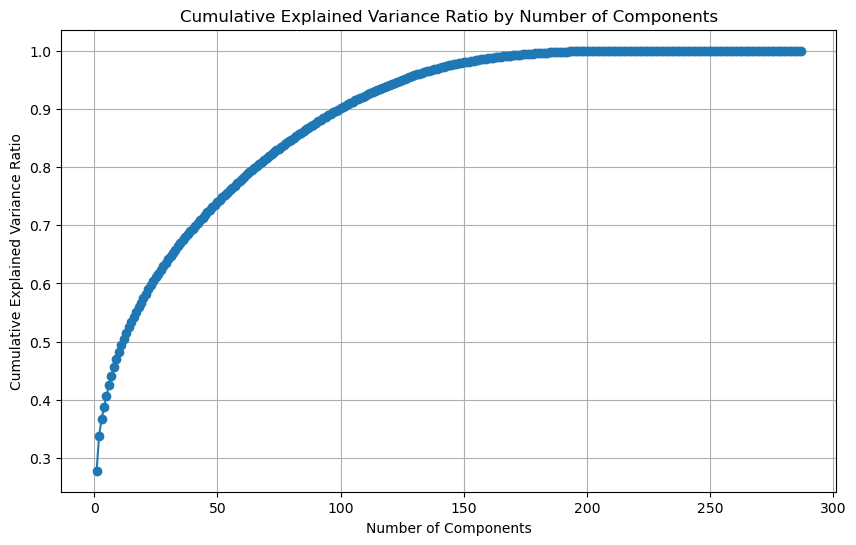

Number of components to explain 95.0% variance: 125


<Figure size 5000x10000 with 0 Axes>

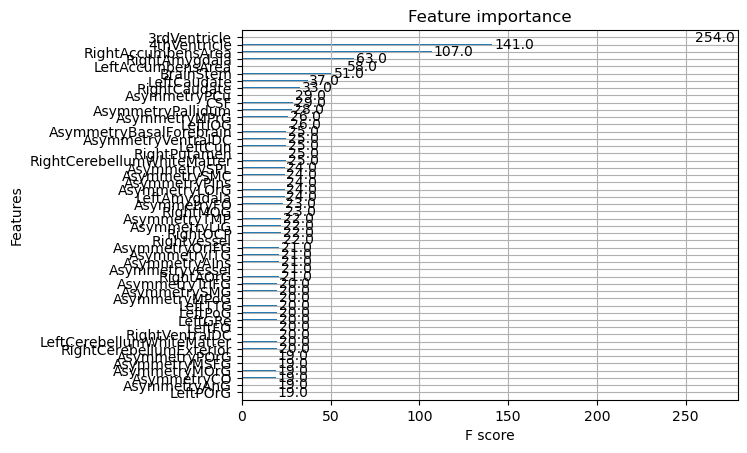

In [137]:
# PCA for dimensionality reduction, the number of components needed for retaining 95% of the variance 
# however, the optimal number of components for each model may chanage to due to optimization of hyperparamters in the traning/test split 
# also train a xgbreggressor model to find the most important features incase we would like to do feature extraction 



# Scale the data and find the umber of components for approximatlly 08-0.95 of the variance 
# Finding best PCA 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)


plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, marker='o', linestyle='-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance Ratio by Number of Components')
plt.grid(True)
plt.show()


threshold = 0.95  



n_components = np.where(cumulative_variance_ratio >= threshold)[0][0] + 1  # Adding 1 because Python uses 0-based indexing
print(f"Number of components to explain {threshold*100}% variance: {n_components}")



# doing a featire imporntance using XGBoost
# this gives an F score of the most important features 

import xgboost as xgb
from xgboost import XGBRegressor
from matplotlib import pyplot
from xgboost import plot_importance

model = XGBRegressor(objective='reg:squarederror')
model.fit(X_train, y_train)


model = XGBRegressor()
model.fit(X, y)

# Increase the figure size to make the plot more spread out and readable
plt.figure(figsize=(50, 100))  # Adjust the dimensions as needed to fit your screen
plot_importance(model, max_num_features=50)  # Plot the top 100 features or as many as you need
plt.show()


# in the end I had chose PCA
# conduting the feature slection within the traning of models was computationally expensive for my computer, when running 5 repeats 


In [ ]:
# Models used for the data, with optimal grid searches:

# please note, these hyperparamteres were subject to change. 
# the optimal model will have the most optimal hyperparameters whcih will be included in the final pipeline



# Linear models: 
# Ridge(alpha = 1000)
# Lasso(alpha = 100)



# non-Linear models:
# SVR(SVR__C = 10)




# Decision tree regression models: for my presentation and anaysis, i will be mainly testing these on the data
# XGBRegressor(max_depth = 4 , alpha = 1.5, eta = 0.1 )
# RandomForesstRegressio(max_depth = 20, n_estimators = 200) 






In [374]:
# Training: 
# here we are going to train the models and apply them to a test set: 
from sklearn.ensemble import RandomForestRegressor




pipeline_final = Pipeline([
    ('standardizer', StandardScaler()),
    ('pca', PCA(n_components=170, random_state=42)),
    ('regression', SVR(C=10))
])




X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #split the data 80-20

cv = RepeatedKFold(n_splits=10, n_repeats=5, random_state=42)  
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')
cv_scores = -cv_scores

print(f"CV Mean Squared Error: {cv_scores.mean()} (± {cv_scores.std() * 2})")


CV Mean Squared Error: 31.264712817026137 (± 8.114789521993629)


In [375]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

#pipeline to the training data
pipeline_final.fit(X_train, y_train)

# predictions
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)





# performance measures for reporting training and testing sets 

r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)


r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)

# Print performance metrics rounded to 2 decimal places
print(f"Training set - R^2: {round(r2_train, 2)}, RMSE: {round(rmse_train, 2)}, MAE: {round(mae_train, 2)}")
print(f"Test set - R^2: {round(r2_test, 2)}, RMSE: {round(rmse_test, 2)}, MAE: {round(mae_test, 2)}")


#========================================================
# dictionary of results: 

# Ridge: 
# Training set - R^2: 0.49, RMSE: 5.15, MAE: 4.11
# Test set - R^2: 0.35, RMSE: 5.79, MAE: 4.69



# Lasso : 
# Training set - R^2: 0.52, RMSE: 4.99, MAE: 4.0
# Test set - R^2: 0.34, RMSE: 5.85, MAE: 4.69


# SVR: 
# Training set - R^2: 0.89, RMSE: 2.43, MAE: 1.16
# Test set - R^2: 0.36, RMSE: 5.84, MAE: 4.67



# XGBRegressor 
# Training set - R^2: 0.94, RMSE: 1.83, MAE: 1.42
# Test set - R^2: 0.28, RMSE: 6.11, MAE: 4.91



#RandomForestRegression 
#Training set - R^2: 0.98, RMSE: 0.54, MAE: 0.66
#Test set - R^2: 0.17, RMSE: 7.01, MAE: 5.43







Training set - R^2: 0.89, RMSE: 2.4, MAE: 1.15
Test set - R^2: 0.36, RMSE: 6.03, MAE: 4.8


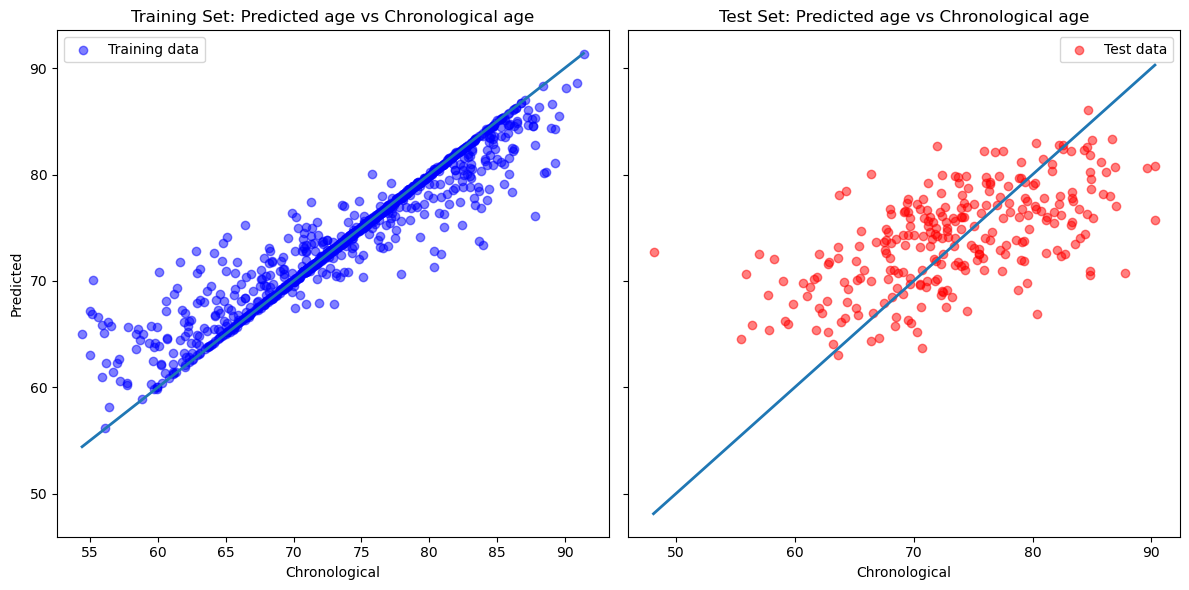

In [379]:
import matplotlib.pyplot as plt

# Actual vs. Predicted values plot
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Training set plot
ax[0].scatter(y_train, y_train_pred, color='blue', alpha=0.5, label = 'Training data')
ax[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],lw=2)
ax[0].set_title('Training Set: Predicted age vs Chronological age')
ax[0].set_xlabel('Chronological')
ax[0].set_ylabel('Predicted')
ax[0].legend()







# Test set plot
ax[1].scatter(y_test, y_test_pred, color='red', alpha=0.5, label='Test data')
ax[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], lw=2)
ax[1].set_title('Test Set: Predicted age vs Chronological age')
ax[1].set_xlabel('Chronological')
ax[1].legend()

plt.tight_layout()
plt.show()


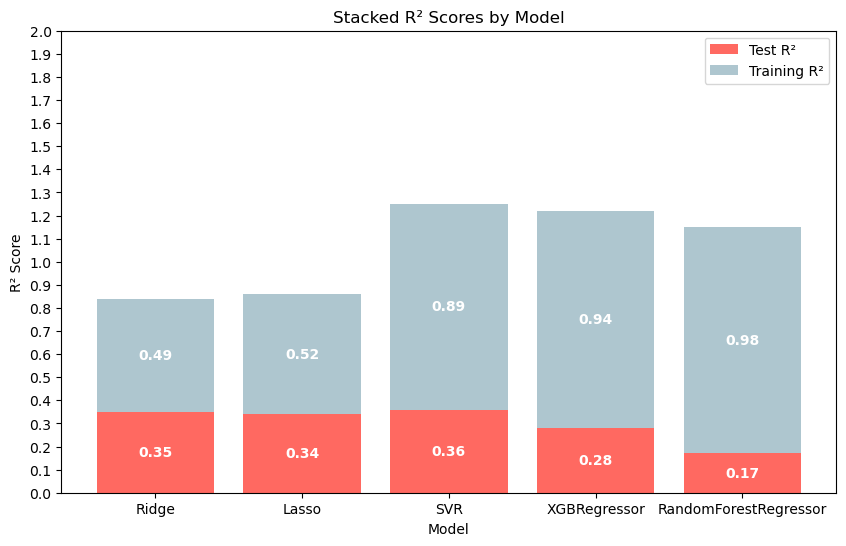

In [354]:
import matplotlib.pyplot as plt
import numpy as np

# Model names and R^2 scores
models = ['Ridge', 'Lasso', 'SVR', 'XGBRegressor', 'RandomForestRegressor']
r2_train = [0.49, 0.52, 0.89, 0.94, 0.98]
r2_test = [0.35, 0.34, 0.36, 0.28, 0.17]

ind = np.arange(len(models))

# Create stacked bar plot for R^2 scores
plt.figure(figsize=(10, 6))

pastel_blue = '#aec6cf'  # Pastel blue color
pastel_red = '#ff6961'  # Pastel red color




plt.bar(ind, r2_test, label='Test R²', color=pastel_red)

# Plot bars for training scores on top of the test scores
plt.bar(ind, r2_train, bottom=r2_test, label='Training R²', color=pastel_blue)


# this is a stacked bar plot, where test will be on the bottom and trainin on top, i think it ust looks better that way 
plt.ylabel('R² Score')
plt.xlabel('Model')
plt.title('Stacked R² Scores by Model')
plt.xticks(ind, models)
plt.yticks(np.arange(0, 2.1, step=0.1))  # Adjust range to account for stacking
plt.legend()

# Annotate the bars with the value of the test scores
for i in range(len(models)):
    plt.annotate(f'{r2_test[i]:.2f}', 
                 (ind[i], r2_test[i] / 2), 
                 ha='center', va='center', color='white', fontweight='bold')
    
    plt.annotate(f'{r2_train[i]:.2f}', 
                 (ind[i], r2_test[i] + r2_train[i] / 2), 
                 ha='center', va='center', color='white', fontweight='bold')

plt.show()







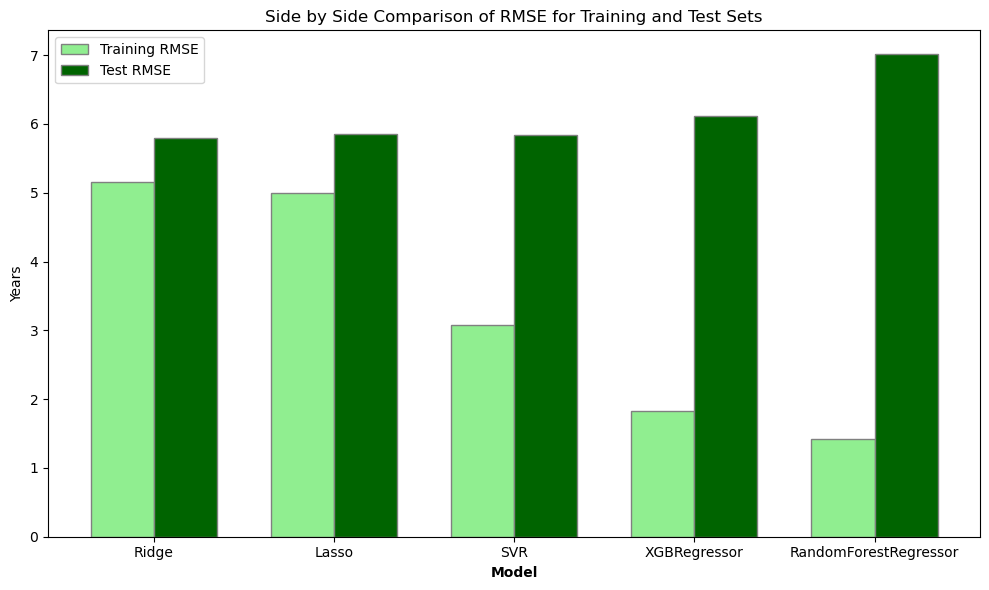

In [359]:
import matplotlib.pyplot as plt
import numpy as np

# Model names and RMSE scores
models = ['Ridge', 'Lasso', 'SVR', 'XGBRegressor', 'RandomForestRegressor']
rmse_train = [5.15, 4.99, 3.08, 1.83, 1.42]  # Sample training RMSE values
rmse_test = [5.79, 5.85, 5.84, 6.11, 7.01]   # Sample test RMSE values




# Plotting code for side by side rmse values of training and test 


r1 = np.arange(len(models))
r2 = [x + bar_width for x in r1]
plt.figure(figsize=(10, 6))
bar_width = 0.35
plt.bar(r1, rmse_train, color='lightgreen', width=bar_width, edgecolor='grey', label='Training RMSE')
plt.bar(r2, rmse_test, color='darkgreen', width=bar_width, edgecolor='grey', label='Test RMSE')
plt.xlabel('Model', fontweight='bold')
plt.ylabel('Years')
plt.xticks([r + bar_width / 2 for r in range(len(r1))], models)
plt.title('Side by Side Comparison of RMSE for Training and Test Sets')
plt.legend()
plt.tight_layout()




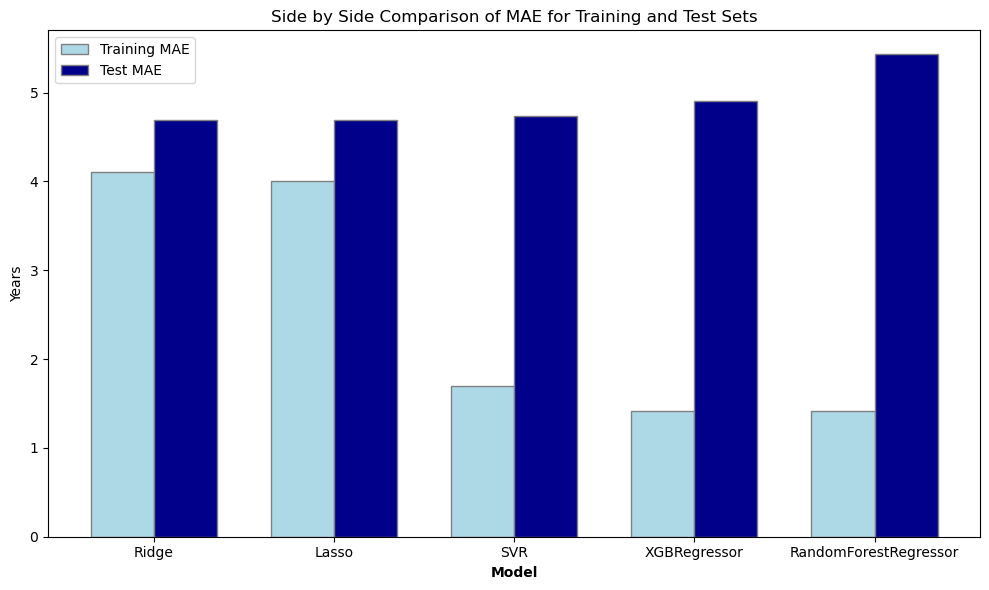

In [360]:
import matplotlib.pyplot as plt
import numpy as np

# Model names and MAE scores
models = ['Ridge', 'Lasso', 'SVR', 'XGBRegressor', 'RandomForestRegressor']
mae_train = [4.11, 4.0, 1.7, 1.42, 1.42]  # Example training MAE values
mae_test = [4.69, 4.69, 4.74, 4.91, 5.43]  # Example test MAE values

# Set position of bar on X axis
r1 = np.arange(len(models))
r2 = [x + bar_width for x in r1]

# Make the plot
plt.figure(figsize=(10, 6))
bar_width = 0.35

plt.bar(r1, mae_train, color='lightblue', width=bar_width, edgecolor='grey', label='Training MAE')
plt.bar(r2, mae_test, color='Darkblue', width=bar_width, edgecolor='grey', label='Test MAE')

# Add xticks on the middle of the group bars
plt.xlabel('Model', fontweight='bold')
plt.ylabel('Years')
plt.xticks([r + bar_width / 2 for r in range(len(r1))], models)
plt.title('Side by Side Comparison of MAE for Training and Test Sets')

# Create legend & Show graphic
plt.legend()
plt.tight_layout()

# Uncomment the following line to show the plot if needed
# plt.show()



In [376]:
from joblib import dump

# Assuming `pipeline` is your trained model pipeline
dump(pipeline_final, 'final_pipeline.joblib')

['final_pipeline.joblib']